# Assignment - Simon's Algorithm

The places where you have enter code are marked with `# YOUR CODE HERE`.

### Question 1 (3 points)

Complete the function `initialize_simon` that creates a quantum circuit consisting of two quantum registers and a classical register for solving Simon's problem.

The function `initialize_simon` has

- Input: $n$ such that you are given a function $f:\{0,1\}^n \rightarrow \{0,1\}$
- Returns: A `QuantumCircuit` object with two quantum registers and a classical register with the correct number of qubits and bits respectively.

In [5]:
%pip install pylatexenc

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136929 sha256=fb644517334cea036301e15e6e7e5e078faf7f07e2818e0a369582ea7eee0555
  Stored in directory: c:\users\keli\appdata\local\pip\cache\wheels\3c\d9\c1\bb2a15d13c742b9035ef7ae6ebe236af270b1d1d9b386dcd5e
Successfully built pylatexenc
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install qiskit qiskit-aer

Note: you may need to restart the kernel to use updated packages.


In [1]:
from qiskit import QuantumRegister, ClassicalRegister

def initialize_simon(n):
    # Do not modify anything above this line
    from qiskit import QuantumCircuit
    
    # Creo dos registros cuánticos de tamaño n y uno clásico de tamaño n
    qr1 = QuantumRegister(n, 'q1')
    qr2 = QuantumRegister(n, 'q2')
    cr = ClassicalRegister(n, 'c')
    
    # Inicializa el circuito con los registros
    qc = QuantumCircuit(qr1, qr2, cr)
    # Do not modify anything below this line  
    return qc

You can use the following cell to test your function.

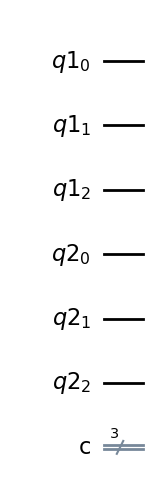

In [2]:
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit

qc = initialize_simon(3)
qc.draw(output='mpl')

### Question 2 (4 points)

Function `simon(n)` returns a single bitstring of length $n$, as a result of running Simon's algorithm. Complete the function `get_y_list` that calls the function `simon()` until $n-1$ bitstrings are found other than the 0 string. 

The function `get_y_list` has

- Input: $n$ 
- Returns: A `list` of bitstrings `y`.

In [10]:
from qiskit import QuantumRegister, ClassicalRegister

def get_y_list(n):
    y_list = []
    # Do not modify anything above this line
    # Iterar hasta que tengamos exactamente n-1 cadenas únicas
    while len(y_list) < n - 1:
        y = simon(n)
        # Ignorar la cadena de puros ceros y evitar duplicados
        if y != "0" * n and y not in y_list:
            y_list.append(y)
    # Do not modify anything below this line  
    return y_list

You can use the following cell to test your function.

In [11]:
# A very limited definition of Simon's function, only to help you test.
# The fully formed Simon's function would be more complicated.
def simon(n):
    import itertools as it
    import random
    x = "11"+"0"*(n-2) #s is the string consisting of all 1's therefore x.s=0 always as there are two 1's in x
    return random.choice([''.join(i) for i in it.permutations(x, n)]+["0"*n])

print(get_y_list(5))

['00101', '00110', '01100', '11000']


### Question 3 (3 points)

Complete the function `oracle` which implements the following function: $f(00)=10$, $f(01)=10$, $f(10)=01$, $f(11)=01$  i.e. when the input is 00, you need to obtain '10' as the measurement outcome of the output register. Input will be encoded in the input register, while the output should be encoded in the output register.  

The function `oracle` has

- Inputs: A `QuantumRegister` object `input_reg` consisting of 2 qubits,  A `QuantumRegister` object `output_reg` consisting of 2 qubits and a `QuantumCircuit` object `qc`  
- Returns: `QuantumCircuit` object `qc`  

Note: Don't forget the Qiskit order.

In [12]:
from qiskit import QuantumRegister, ClassicalRegister

def oracle(input_reg,output_reg,qc):
    # Do not modify anything above this line
    # Aplicar NOT al output_reg[1] para que por defecto sea 1 (estado inicial '10')
    qc.x(output_reg[1])
    
    # Si input_reg[1] es 1, invertimos output_reg[1] (pasa de 1 a 0)
    qc.cx(input_reg[1], output_reg[1])
    
    # Si input_reg[1] es 1, invertimos output_reg[0] (pasa de 0 a 1)
    qc.cx(input_reg[1], output_reg[0])
    
    return qc

You can use the following cell to test your function. Inputs and the outputs should match the function given above.

In [13]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator

def test(input_state):
    input_reg = QuantumRegister(2)
    output_reg = QuantumRegister(2)
    creg = ClassicalRegister(2)
    qc = QuantumCircuit(input_reg, output_reg, creg)
    
    #initialization
    if input_state[0]=="1":
        qc.x(input_reg[1])
    elif input_state[1]=="1":
        qc.x(input_reg[0])
    
    #call oracle
    oracle(input_reg,output_reg,qc)
    
    qc.measure(output_reg,creg)

    job = AerSimulator().run(qc,shots=1)
    counts = job.result().get_counts()
    return counts

for s in ["00","01","10","11"]:
    print("Input:" ,s, "Output:", test(s))

Input: 00 Output: {'10': 1}
Input: 01 Output: {'10': 1}
Input: 10 Output: {'01': 1}
Input: 11 Output: {'01': 1}
